In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arhamrumi/amazon-product-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-product-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-product-reviews


In [2]:
ls /root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1

Reviews.csv


##Install & Import libraries


In [3]:
!pip install wordcloud -q

import pandas as pd
import numpy as np
import re
import string
import glob
import os

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##Load the dataset

In [4]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1/Reviews.csv')
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


##Build the sentiment label from Score

In [5]:
df = df[['Text', 'Score']].dropna()
df = df[df['Score'] != 3]
df['sentiment'] = df['Score'].apply(lambda s: 1 if s > 3 else 0)  # 1=positive, 0=negative

print(df['sentiment'].value_counts())
print("Total rows:", df.shape)

sentiment
1    443777
0     82037
Name: count, dtype: int64
Total rows: (525814, 3)


##Clean & preprocess text

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)               # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)      # remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', ' ', text)                 # remove numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head()

,Text,clean_text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


##Train/test split

In [7]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Convert text to numerical format (TF-IDF)

In [8]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Train the classifier (Logistic Regression)

In [9]:
log_reg = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, class_weight='balanced')
log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'positive']))

=== Logistic Regression ===
Accuracy: 0.9246598138128429
              precision    recall  f1-score   support

    negative       0.70      0.92      0.79     16407
    positive       0.98      0.93      0.95     88756

    accuracy                           0.92    105163
   macro avg       0.84      0.92      0.87    105163
weighted avg       0.94      0.92      0.93    105163



##Confusion Matrix

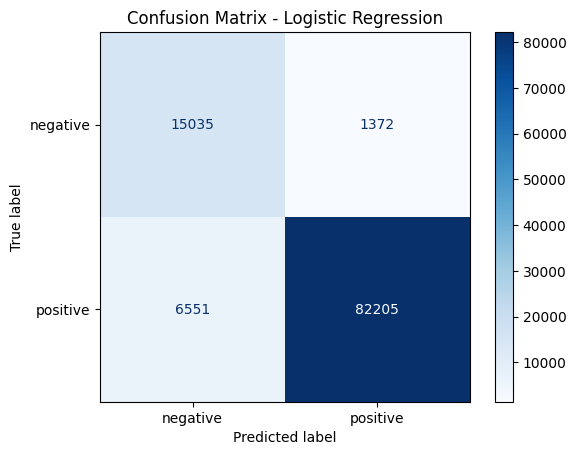

In [10]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

##Naive Bayes comparison

In [11]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
y_pred_nb = nb.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=['negative', 'positive']))

print(f"\nComparison -> Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f} "
      f"| Naive Bayes: {accuracy_score(y_test, y_pred_nb):.4f}")

=== Naive Bayes ===
Accuracy: 0.8945731863868471
              precision    recall  f1-score   support

    negative       0.61      0.88      0.72     16407
    positive       0.98      0.90      0.93     88756

    accuracy                           0.89    105163
   macro avg       0.79      0.89      0.83    105163
weighted avg       0.92      0.89      0.90    105163


Comparison -> Logistic Regression: 0.9247 | Naive Bayes: 0.8946


##Most frequent positive/negative words (bar chart)

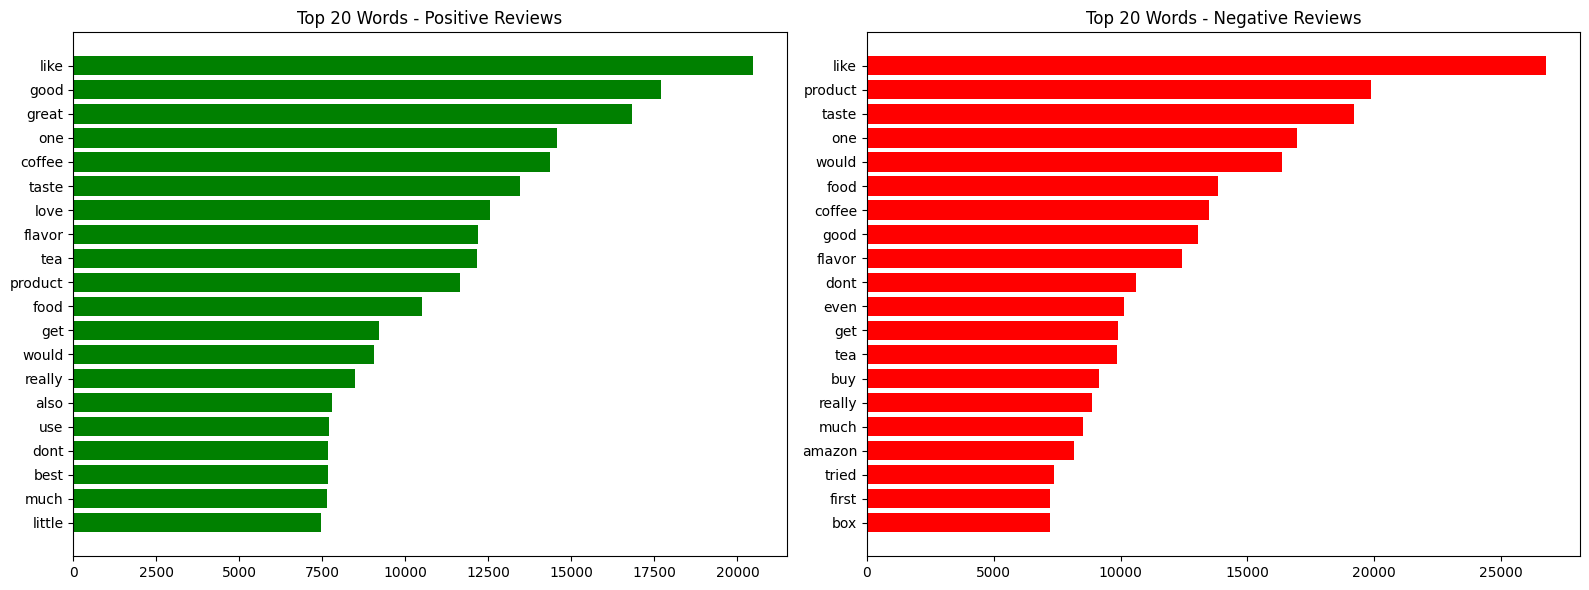

In [12]:
def top_words(text_series, n=20, sample_size=50000):
    if len(text_series) > sample_size:
        text_series = text_series.sample(sample_size, random_state=42)
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

pos_words = top_words(df[df['sentiment'] == 1]['clean_text'])
neg_words = top_words(df[df['sentiment'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh([w for w, c in pos_words[::-1]], [c for w, c in pos_words[::-1]], color='green')
axes[0].set_title("Top 20 Words - Positive Reviews")

axes[1].barh([w for w, c in neg_words[::-1]], [c for w, c in neg_words[::-1]], color='red')
axes[1].set_title("Top 20 Words - Negative Reviews")

plt.tight_layout()
plt.show()

##Word Clouds

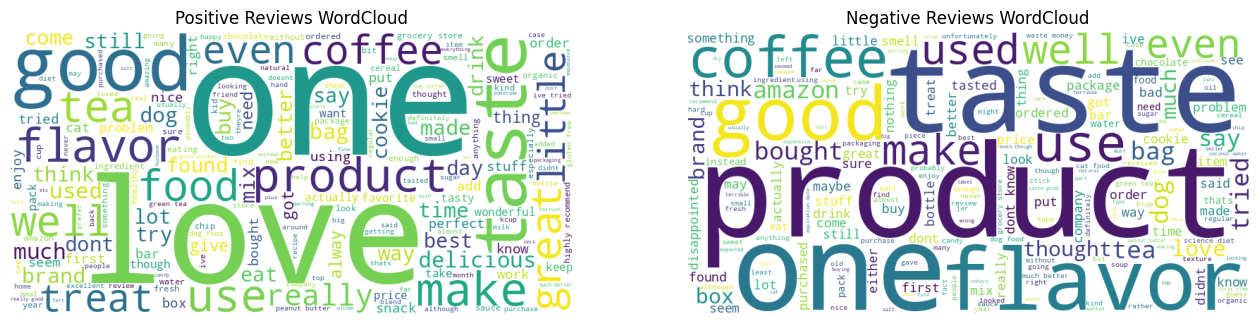

In [13]:
sample_pos = df[df['sentiment'] == 1]['clean_text'].sample(min(50000, (df['sentiment']==1).sum()), random_state=42)
sample_neg = df[df['sentiment'] == 0]['clean_text'].sample(min(50000, (df['sentiment']==0).sum()), random_state=42)

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(" ".join(sample_pos))
wc_neg = WordCloud(width=800, height=400, background_color='white').generate(" ".join(sample_neg))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_pos); axes[0].axis('off'); axes[0].set_title("Positive Reviews WordCloud")
axes[1].imshow(wc_neg); axes[1].axis('off'); axes[1].set_title("Negative Reviews WordCloud")
plt.show()